<a target="_blank" href="https://colab.research.google.com/github/SLCFLAB/SamsungDS/blob/master/OP_Day_1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## 1. 미분법, 적분법 수업 내용 요약

In [1]:
# 아래 사이트 참고 해주세요 :)

# https://ko.wikipedia.org/wiki/미분법
# https://ko.wikipedia.org/wiki/적분표

## 2. Sympy

In [2]:
pip install sympy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# 튜토리얼은 아래 사이트 참고
# https://docs.sympy.org/latest/tutorial/calculus.html

# 설치는 아래 코드
#!conda install sympy
# 혹은 터미널창에서 conda install sympy

from sympy import *

In [4]:
# 기호를 정의 해야함.

x, y, z, t = symbols('x y z t')
k, m, n = symbols('k m n', integer=True)
f, g, h = symbols('f g h', cls=Function)

In [5]:
# 프린트 latex형태로 안나올 때

init_printing(use_latex='mathjax')

## 3. Differentials

In [6]:
# x로 cos(x)를 미분

diff(cos(x), x)

-sin(x)

In [7]:
# x로 exp(x^2)를 미분

diff(exp(x**2), x)

     ⎛ 2⎞
     ⎝x ⎠
2⋅x⋅ℯ    

In [8]:
# x로 x^4를 세번 미분

diff(x**4, x, x, x)

24⋅x

In [9]:
# exp(xyz)를 x로 한번 미분, y로 2번 미분, z로 4번 미분

diff(exp(x*y*z), x, y, y, z, z, z, z) # diff(exp(x*y*z), x, y, 2, z, 4) 같은 의미

 3  2 ⎛ 3  3  3       2  2  2                ⎞  x⋅y⋅z
x ⋅y ⋅⎝x ⋅y ⋅z  + 14⋅x ⋅y ⋅z  + 52⋅x⋅y⋅z + 48⎠⋅ℯ     

In [10]:
# 편미분 기호로 표현하고 싶을 때

deriv = Derivative(exp(x*y*z), x, y, y, z, 4)
deriv

     7            
    ∂     ⎛ x⋅y⋅z⎞
──────────⎝ℯ     ⎠
  4   2           
∂z  ∂y  ∂x        

In [11]:
# deriv의 값을 알고 싶을 때

deriv.doit()

 3  2 ⎛ 3  3  3       2  2  2                ⎞  x⋅y⋅z
x ⋅y ⋅⎝x ⋅y ⋅z  + 14⋅x ⋅y ⋅z  + 52⋅x⋅y⋅z + 48⎠⋅ℯ     

In [12]:
func = x**3+y**3+(x-1)**2+(y-2)**2 + log(x) + exp(y)
diff(func, x)

   2             1
3⋅x  + 2⋅x - 2 + ─
                 x

In [13]:
diff(func, y)

   2          y    
3⋅y  + 2⋅y + ℯ  - 4

In [14]:
diff(func, x, y)

0

# 4. Integrals

In [15]:
integrate(cos(x), x)

sin(x)

In [16]:
integrate(exp(-x), x)

  -x
-ℯ  

In [17]:
# 정적분 값을 알고 싶을 때
# (function, (integration_variable, lower_limit, upper_limit))
# infinity = 소문자 알파벳 o를 두번 입력

integrate(exp(-x), (x, 0, oo))

1

In [18]:
integrate(exp(-x**2 - y**2), (x, -oo, oo), (y, -oo, oo))

π

In [19]:
# 적분 기호로 표현하고 싶을 때

expr = Integral(log(x)**2, x)
expr

⌠           
⎮    2      
⎮ log (x) dx
⌡           

In [20]:
# 적분 값을 알고 싶을 때

expr.doit()

     2                      
x⋅log (x) - 2⋅x⋅log(x) + 2⋅x

In [21]:
expr = Integral(3*x*x+3*y*y+1/x+exp(y), x)
expr

⌠                          
⎮ ⎛   2      2    y   1⎞   
⎮ ⎜3⋅x  + 3⋅y  + ℯ  + ─⎟ dx
⎮ ⎝                   x⎠   
⌡                          

In [22]:
expr.doit()

 3     ⎛   2    y⎞         
x  + x⋅⎝3⋅y  + ℯ ⎠ + log(x)

# 5. Taylor series

In [23]:
x = Symbol('x')
f = sqrt(1+x)
f_taylor = f.series(x, x0=1, n=4)
display(f_taylor)

                            2             3                     
     √2⋅(x - 1)   √2⋅(x - 1)    √2⋅(x - 1)     ⎛       4       ⎞
√2 + ────────── - ─────────── + ─────────── + O⎝(x - 1) ; x → 1⎠
         4             32           128                         

In [24]:
f_taylor_valid = f_taylor.removeO()
display(f_taylor_valid)

          3             2                  
√2⋅(x - 1)    √2⋅(x - 1)    √2⋅(x - 1)     
─────────── - ─────────── + ────────── + √2
    128            32           4          

In [25]:
x = Symbol('x')
y = Symbol('y')
f = tan(y/(1+x))
display(f)

   ⎛  y  ⎞
tan⎜─────⎟
   ⎝x + 1⎠

In [26]:
num_order = 4
f_taylor = f.series(x, 0, num_order).removeO().series(y, 0, num_order).removeO()
display(f_taylor)

   ⎛      3               ⎞                        
 3 ⎜  10⋅x       2       1⎟     ⎛   3    2        ⎞
y ⋅⎜- ───── + 2⋅x  - x + ─⎟ + y⋅⎝- x  + x  - x + 1⎠
   ⎝    3                3⎠                        

# 6. Grad, Hessian

In [ ]:
pip install numdifftools

Note: you may need to restart the kernel to use updated packages.


In [48]:
import numpy as np
import numdifftools as nd
import matplotlib.pyplot as plt
import copy
import time

## numdifftools 사용 방법
공식 documentation : https://numdifftools.readthedocs.io/en/master/index.html

In [40]:
fun = lambda x : 4*x[1]**3+x[0]**2-12*x[1]**2-36*x[1]+2

In [41]:
g = nd.Gradient(fun)

In [42]:
g([1,1])

array([  2., -48.])

In [30]:
H = nd.Hessian(fun)

In [31]:
H(np.array([1, 1]))

array([[2., 0.],
       [0., 0.]])

예시 $f(\bold x) = f(x_1, x_2, x_3) = 3x^2_1 x_2 + x^3_2 x_3 + x_3 x^2_1$

In [39]:
x_1, x_2, x_3 = symbols('x_1 x_2 x_3')
f = 3*x_1**2*x_2 + x_2**3*x_3 + x_3*x_1**2
display(f)

    2        2        3   
3⋅x₁ ⋅x₂ + x₁ ⋅x₃ + x₂ ⋅x₃

In [ ]:
# gradient of f

grad_f = [diff(f, var) for var in (x_1, x_2, x_3)]
display(grad_f)

⎡                       2       2       2     3⎤
⎣6⋅x₁⋅x₂ + 2⋅x₁⋅x₃, 3⋅x₁  + 3⋅x₂ ⋅x₃, x₁  + x₂ ⎦

In [ ]:
# hessian of f

hessian_f = hessian(f, (x_1, x_2, x_3))
display(hessian_f)

⎡6⋅x₂ + 2⋅x₃   6⋅x₁    2⋅x₁ ⎤
⎢                           ⎥
⎢                          2⎥
⎢   6⋅x₁      6⋅x₂⋅x₃  3⋅x₂ ⎥
⎢                           ⎥
⎢                  2        ⎥
⎣   2⋅x₁       3⋅x₂      0  ⎦

## Contour map의 gradient 시각화

In [ ]:
x,y = symbols('x y')
f = x**2 + y**2

grad_f = [diff(f, var) for var in (x, y)]
print("Symbolic gradient:", grad_f)

Symbolic gradient: [2*x, 2*y]


In [ ]:
# gradient at (1,1)

grad_f_eval = [expr.subs({x: 1, y: 1}) for expr in grad_f]
print("Gradient at (1,1):", grad_f_eval)

Gradient at (1,1): [2, 2]


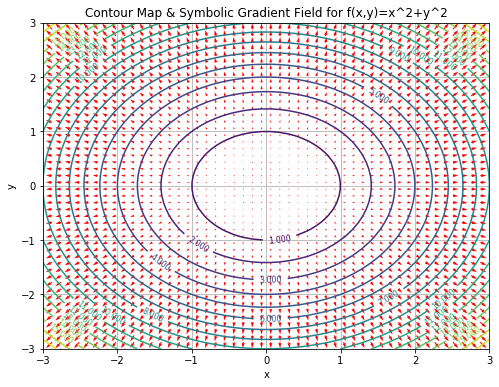

In [ ]:
# sympy 식을 numpy에서 사용할 수 있도록 람다 함수로 변환
#    f_func는 f(x,y)를 계산하는 함수, grad_func_x, grad_func_y는 gradient의 각 성분
f_func       = lambdify((x, y), f, 'numpy')
grad_func_x  = lambdify((x, y), grad_f[0], 'numpy')
grad_func_y  = lambdify((x, y), grad_f[1], 'numpy')

# numpy를 사용해 격자(grid) 생성 및 함수 값과 gradient 값을 계산
x_vals = np.linspace(-3, 3, 50) # -3부터 3까지 격자점이 50개인 1차원 배열
y_vals = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_vals, y_vals) # 2차원 평면을 생성
# X, Y는 각각 x와 y 좌표에 해당하는 2차원 배열
 
Z = f_func(X, Y)
U = grad_func_x(X, Y)
V = grad_func_y(X, Y)

# contour plot과 gradient vector field 시각화
plt.figure(figsize=(8,6))
# f(x,y)의 등고선을 그림
contours = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# quiver 플롯: 각 점에서의 gradient를 화살표로 나타냄 (빨간색)
plt.quiver(X, Y, U, V, color='red')

plt.title('Contour Map & Symbolic Gradient Field for f(x,y)=x^2+y^2')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()